# Разработка алгоритма имитации отжига

In [1]:
import numpy as np
import networkx as nx
import pandas as pd
import geopandas as gpd
import osmnx as ox
import random
from matplotlib import pyplot as plt
import math



from genesis.core import BestPointsBase, MetricBase, StateBase
from genesis.metrics import ArrivalTime, CoverIndex
from genesis.states import FirstArrivalUnitState
from genesis.tools import list_dict_concat
from genesis.swiss_knife import CMAP_GrGldRd
from genesis.utils import timing

In [2]:
# Загрузка графа и полигона границ
G = ox.load_graphml("tests/data/test_rng.ml")
area = gpd.read_file("tests/data/test_polygon.gpkg")

In [3]:
def iter_state_func(**kwds):
    '''
    Печать состояния расчета на итерации
    '''
    # print('Итерация:', kwds['i'])
    print(kwds)
    dynamic_nodes = kwds['dynamic_nodes']
    if isinstance(dynamic_nodes, dict):
        dynamic_nodes_id = list(dynamic_nodes.keys())
    else:
        dynamic_nodes_id = dynamic_nodes

    try:
        static_nodes = kwds['static_nodes']
        if isinstance(static_nodes, dict):
            static_nodes_id = list(static_nodes.keys())
        else:
            static_nodes_id = static_nodes
    except:
        static_nodes = None
        
    if not static_nodes is None:
        if isinstance(dynamic_nodes,list):
            start_nodes = dynamic_nodes+static_nodes
        elif isinstance(dynamic_nodes,dict):
            start_nodes = {**dynamic_nodes, **static_nodes}
    else:
        start_nodes = dynamic_nodes
    times, nearest = FirstArrivalUnitState()(env=G, points=start_nodes)
    times = {k:(1+int(t//5))*5 for k, t in times.items()}

    nx.set_node_attributes(G, pd.Series(nearest, dtype=str), 'nearest')
    nx.set_node_attributes(G, times, 'route_time')

    nds = ox.graph_to_gdfs(G, edges=False)
    fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,6))
    ox.plot_graph(G, edge_linewidth=0.2, node_size=0, show=False, ax=ax1)
    nds.plot(ax=ax1, markersize=2, column='nearest', cmap='Set3', legend=True)
    nds.loc[dynamic_nodes_id].plot(ax=ax1, markersize=25, color='red')
    if static_nodes:
        nds.loc[static_nodes_id].plot(ax=ax1, markersize=25, color='k')

    ox.plot_graph(G, edge_linewidth=0.2, node_size=0, show=False, ax=ax2)
    nds.plot(ax=ax2, markersize=2, column='route_time', cmap=CMAP_GrGldRd, legend=True)
    nds.loc[dynamic_nodes_id].plot(ax=ax2, markersize=25, color='red')
    if static_nodes:
        nds.loc[static_nodes_id].plot(ax=ax2, markersize=25, color='k')

    plt.show()

class EpochEndFunction:
    def __init__(self):
        self.history=[]

    def __call__(self, **kwargs):
        print(kwargs, end='\r')
        self.history.append(kwargs)

In [4]:
class BestNodeSA(BestPointsBase):
    '''
    Поиск лучших узлов для размещения n объектов.

    Расчет производится алгоритмом имитации отжига.

    ## Область применения
    Определение размещения множества узлов в графе, при котором 
    обеспечиваются наилучшие некоторые целевые метрики. 
    
    Дает решение высокой точности. Хорошо подходит для больших графов.
    '''
    def __init__(self, state_function: StateBase,
                 metric_function: MetricBase,
                 initial_temperature=1,
                 end_temperature=0.0001,
                 turns=1000000,
                 mutation_max_count:int = 1,
                 appr_val_in_area:float = 0,
                 bad_val_in_area:int = 1000,
                 turn_end_function:callable = None,
                 best_state_find_function:callable = None,
                 **kwargs) -> None:
        '''
        ## Аргументы
        `state_function`: StateBase
            функция расчета состояния окружения
        `metric_function`: MetricBase
            Функция расчета метрики
        `initial_temperature`: float  = 1
            Начальная температура
        `end_temperature`: float=0.0001
            Конечная температура
        `mutation_max_count`: int = 1
            Максимальное количество единиц мутации.
        `appr_val_in_area`: int=0
            Доля узлов графа в пределах area, покрытие которой считается приемлемой для принятия расчетной метрики. 
            Если при расчете метрик, из стартового узла (узлов) достижимо меньшее количество узлов,
            то такой узел не рассматривается.
            При расчет размещения нескольких узлов неминуемо возникает ситуация при которой
            часть территории area будет недостижима. Поэтому по умолчанию считается
        `bad_val_in_area`: int=1000
            Значение указываемое для узла, в случае если
            из него нельзя попасть в `appr_val_in_area` долю узлов в пределах
            `area`.
        `turn_end_function`: callable  = None
            Функция вызываемая на каждой итерации расчета.
        `best_state_find_function`: callable = None
            Функция вызываемая после каждого улучшения абсолютного оптимума.
        '''

        self.initial_temperature = initial_temperature
        self.end_temperature = end_temperature
        self.turns = turns
        self.appr_val_in_area = appr_val_in_area
        self.mutation_max_count = mutation_max_count
        self.bad_val_in_area = bad_val_in_area
        self.turn_end_function = turn_end_function
        self.best_state_find_function = best_state_find_function
        super().__init__(state_function, metric_function, **kwargs)


    def _decrease_temperature(self, T0, t):
        '''
        Функция изменения температуры

        T0 - начальная температура

        t - текущая итерация

        ВОЗВРАЩАЕТ
        ----------
        Температура на итерации t
        '''
        return T0/(1+t)

    def _get_transition_probability(self, dE, T):
        '''
        Функция расчета вероятности перехода из состояния i в состояние j
        `dE` - энергия перехода
        `T` - температура

        ВОЗВРАЩАЕТ
        ----------
        Вероятность перехода
        '''

        return math.exp(-dE/T)

    def _calculate_energy(self, env, nodes, area=None, **kwargs):
        '''
        Расчет энергии состояния.
        Здесь это значение целевой метрики.
        '''
        # 1. Расчет состояния
        times, _ = self.state_function(env=env, points=nodes, area=area, **kwargs)

        if not area is None:
            appr_nodes_count = area.sum() * self.appr_val_in_area
            if len(times) < appr_nodes_count:
                print('Расстановка не обеспечивает требуемую степень прикрытия территории area')
                return self.bad_val_in_area

        # 2. Расчет стартовой метрики состояния и определение стартового размещения
        best_metric = self.metric_function(times, **kwargs)

        return best_metric

    def _generate_state_candidate(self, state, g_nodes):
        '''
        Функция порождает новое состояние
        '''
        new_state = state.copy()

        # Здесь вся магия
        for _ in range(self.mutation_max_count):
            # if random.random() < self.mutation_rate:
            # Выбор случайного элемента в словаре и удаление его из new_dynamic_nodes
            node, unit = random.choice(list(new_state.items()))
            del new_state[node]

            # Поиск нового узла, котрого при этом нет в new_dynamic_nodes
            node = random.choice(g_nodes)
            while node in new_state.keys():
                node = random.choice(g_nodes)

            new_state[node] = unit

        # Возвращаем новое состояние
        return new_state

    def _is_transition(self, probability):
        value = random.random()
        return value <= probability

    def __call__(self,
                 env,
                 dynamic_nodes: dict,
                 static_nodes: dict = None,
                 area=None,
                 **kwargs):
        '''
        Запуск работы алгоритма имитации отжига

        ## Аргументы
        `env`:nx.MultiDiGraph
            Граф улично-дорожной сети
        `dynamic_nodes`: list|dict
            Список стартовых узлов графа в которых размещены
            подразделения оптимальные места которых следует определить.
        `static_nodes`: list|dict = None
            Список стартовых узлов графа в которых размещены
            подразделения изменять размещение которых не следует.
        `area`: pd.Series = None
            Маска узлов графа. Значениями True отмечены узлы графа - цели расчета леса Вороного.
            Если не указана, расчет производится для всех узлов графа.
        '''
        
        # 0. Проверяем пришедшие данные
        if not isinstance(env, nx.MultiDiGraph):
            raise TypeError("Тип аргумента `env` должен быть `MultiDiGraph`!")
        if not isinstance(dynamic_nodes, dict):
            raise TypeError("Тип аргумента `dynamic_nodes` должен быть `dict`!")
        if not static_nodes is None and not isinstance(static_nodes, dict):
            raise TypeError("Тип аргумента `static_nodes` должен быть `dict`!")
        if len(dynamic_nodes) < 2:
            raise ValueError(f'Количество элементов `dynamic_nodes` не может быть меньше 2. Сейчас {len(dynamic_nodes)}')
        if not area is None and not isinstance(area, pd.Series):
            raise TypeError(f'Аргумент `area` должен иметь тип `pd.Series`! Имеет {type(area)}')

        if static_nodes is None:
            static_nodes = {}
        g_nodes = list(env.nodes())

        # 1. Рассчитываем исходное состояние и энергию, устанавливаем начальную температуру
        best_state = dynamic_nodes
        current_state = dynamic_nodes

        current_energy = self._calculate_energy(env=env,
                                      nodes=list_dict_concat(current_state, static_nodes),
                                      area=area,
                                      **kwargs)
        best_energy = current_energy
        T = self.initial_temperature

        # 2. Выполняем расчет
        for i in range(self.turns):
            state_candidate = self._generate_state_candidate(current_state, g_nodes)
            candidate_energy = self._calculate_energy(env=env,
                                nodes=list_dict_concat(state_candidate, static_nodes),
                                area=area,
                                **kwargs)

            if candidate_energy < current_energy:
                current_energy = candidate_energy
                current_state = state_candidate
                if current_energy <= best_energy:       # Здесь проверку на тип оптимизации (мин/макс)
                    best_energy = current_energy
                    best_state = state_candidate
                    # pd.DataFrame(best_state.items()).to_excel('best_state.xlsx')
                    # print(i, T, best_energy, sep='\t')
                    # Выполнение функции окончания расчета на эпохе
                    if self.best_state_find_function:
                        self.best_state_find_function(turn=i,
                                                T = T,
                                                best_metric=best_energy,
                                                cur_metric=candidate_energy,
                                                best_bot=best_state)
            else:
                p = self._get_transition_probability(candidate_energy-current_energy, T)
                if self._is_transition(p):
                    current_energy = current_energy
                    currentState = state_candidate

            T = self._decrease_temperature(self.initial_temperature, i)
            if T < self.end_temperature:
                return currentState, best_state
            
            # Выполнение функции окончания расчета на эпохе
            if self.turn_end_function:
                self.turn_end_function(turn=i,
                                        T = T,
                                        best_metric=best_energy,
                                        cur_metric=candidate_energy,
                                        best_bot=best_state)

        return best_state, best_energy



def epoch_end_function(turn, best_metric, cur_metric, **kwargs):
    T = round(kwargs['T'], 4)
    print(f'Эпоха: {turn} |', f'T={T} |', f'Лучшая метрика: {best_metric} |', f'Текущая метрика: {cur_metric} |')

eef = EpochEndFunction()


nodes = list(G.nodes())
existed_units = {nodes[100]: 'A',
        nodes[2000]: 'B',
        }
new_units = {nodes[3000]: 'c',
            nodes[4000]: 'd'}
ns = ox.graph_to_gdfs(G, edges=False)
points_mask = ns.within(area.iloc[0].geometry)


BNSA = timing(BestNodeSA(FirstArrivalUnitState(),
                    ArrivalTime(),
                    # end_temperature = 0.00001,
                    # turn_end_function = eef,
                    best_state_find_function=epoch_end_function,
                    ))

optimal_nodes, best_metric = BNSA(env=G, 
                                  static_nodes=existed_units,
                                  dynamic_nodes=new_units,
                                  area=points_mask,
                                  )

print(optimal_nodes, best_metric)

Эпоха: 0 | T=1 | Лучшая метрика: 5.076368324924964 | Текущая метрика: 5.076368324924964 |
Эпоха: 1 | T=1.0 | Лучшая метрика: 4.134184893543649 | Текущая метрика: 4.134184893543649 |est_bot': {2760591335: 'c', 2054468337: 'd'}}
Эпоха: 2 | T=0.5 | Лучшая метрика: 4.004552501596526 | Текущая метрика: 4.004552501596526 |est_bot': {2054468337: 'd', 2034401345: 'c'}}
Эпоха: 29 | T=0.0345 | Лучшая метрика: 3.845546665208506 | Текущая метрика: 3.845546665208506 |4883293952, 'best_bot': {2034401345: 'c', 2054468929: 'd'}}}
Эпоха: 38 | T=0.0263 | Лучшая метрика: 3.5744323229133403 | Текущая метрика: 3.5744323229133403 |2236413, 'best_bot': {2034401345: 'c', 5574296090: 'd'}}}
Эпоха: 39 | T=0.0256 | Лучшая метрика: 3.465598897981991 | Текущая метрика: 3.465598897981991 |23229133403, 'best_bot': {5574296090: 'd', 4116050305: 'c'}}
Эпоха: 89 | T=0.0112 | Лучшая метрика: 3.328072138674245 | Текущая метрика: 3.328072138674245 |84743278625, 'best_bot': {4116050305: 'c', 9085465287: 'd'}}
Эпоха: 551 | 

{'dynamic_nodes': {2034401367: 'c', 8922575115: 'd'}, 'static_nodes': {1296599762: 'A', 2042076750: 'B'}}


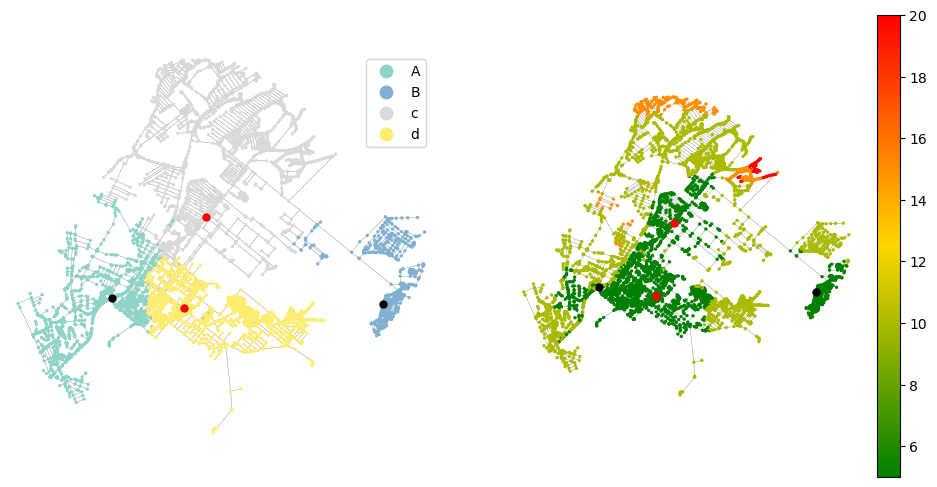

In [5]:
# Печать карт размещения и прибытия
# iter_state_func(dynamic_nodes=new_units, static_nodes=existed_units)
iter_state_func(dynamic_nodes=optimal_nodes, static_nodes=existed_units)

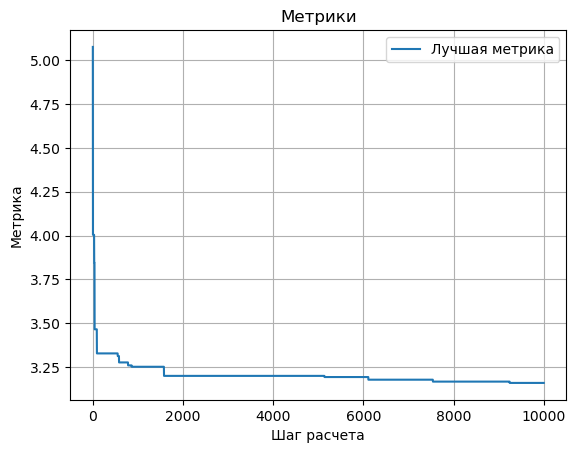

In [6]:
df = pd.DataFrame(eef.history)

fig, ax  = plt.subplots(1,1)
ax.plot(range(len(df)), df['best_metric'], label='Лучшая метрика')
# ax.plot(range(len(df)), df['cur_metric'], label='Текущая метрика')
ax.legend()
ax.set_xlabel('Шаг расчета')
ax.set_ylabel('Метрика')
ax.set_title('Метрики')
ax.grid()

In [7]:
start_nodes = {**optimal_nodes, **existed_units}
times, _ = FirstArrivalUnitState()(env=G, points=start_nodes)   #, area=points_mask)
best_metric = ArrivalTime()(times)
best_metric

5.466111013042462

# GigaCode

Класс `BestNodeSA` реализует алгоритм имитации отжига для поиска оптимального размещения объектов. В конструкторе класса задаются начальная температура, конечная температура, количество итераций, максимальное количество мутаций и функции для обработки конца итерации и поиска наилучшего состояния.

Метод `_decrease_temperature` изменяет температуру на каждой итерации. Метод `_get_transition_probability` вычисляет вероятность перехода к новому состоянию. Метод `_calculate_energy` вычисляет энергию состояния, которая в данном случае является значением целевой метрики.

Метод `_generate_state_candidate` генерирует новое состояние путем случайного изменения текущего состояния. Метод `_is_transition` проверяет, происходит ли переход к новому состоянию.

В методе `__call__` происходит основной цикл алгоритма имитации отжига. На каждой итерации генерируется новое состояние, вычисляется его энергия и сравнивается с энергией текущего состояния. Если энергия нового состояния меньше энергии текущего состояния, то новое состояние становится текущим состоянием. В противном случае, с вероятностью, зависящей от разницы энергий, происходит переход к новому состоянию.

В конце каждой итерации вызываются функции для обработки конца итерации и поиска наилучшего состояния.